In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree  
from sklearn.metrics import confusion_matrix


In [2]:
data = pd.read_csv('data/titanic_org.csv').dropna()

In [3]:
data = data.drop(columns = ['PassengerId', 'Name', 'Ticket', 'Cabin', 'Embarked'])
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
1,1,1,female,38.0,1,0,71.2833
3,1,1,female,35.0,1,0,53.1000
6,0,1,male,54.0,0,0,51.8625
10,1,3,female,4.0,1,1,16.7000
11,1,1,female,58.0,0,0,26.5500


In [4]:
pd.get_dummies(data['Sex'], dtype='int64').head()

,female,male
1,1,0
3,1,0
6,0,1
10,1,0
11,1,0


In [5]:
data['Sex'] =pd.get_dummies(data['Sex'], dtype='int64')['female']
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
1,1,1,1,38.0,1,0,71.2833
3,1,1,1,35.0,1,0,53.1000
6,0,1,0,54.0,0,0,51.8625
10,1,3,1,4.0,1,1,16.7000
11,1,1,1,58.0,0,0,26.5500


In [6]:
X = data.drop(['Survived'], axis = 1) # input features
y = data['Survived'] # target features
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=20)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(137, 6) (46, 6) (137,) (46,)


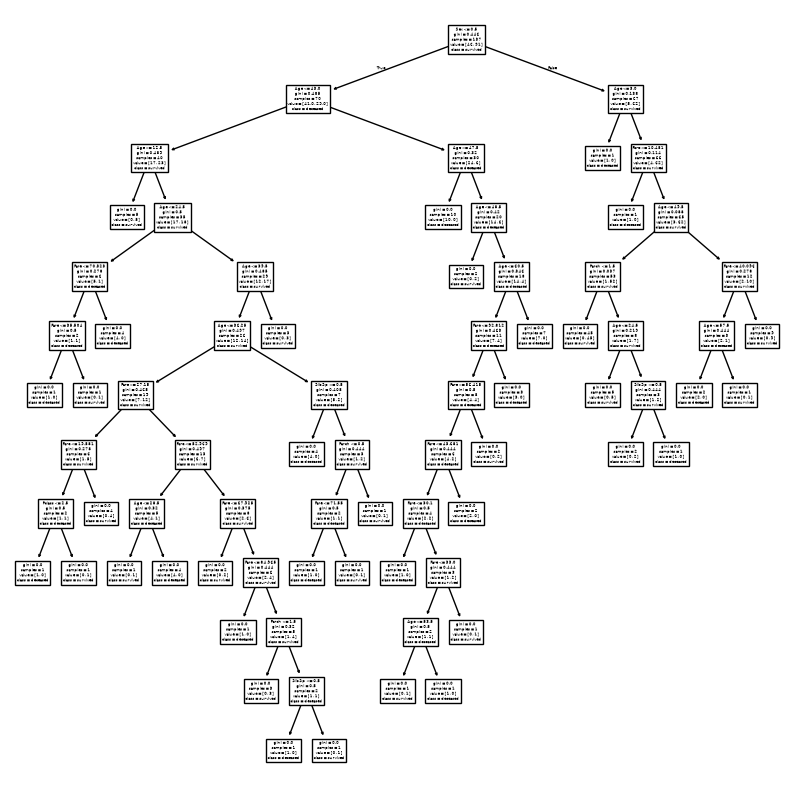

In [7]:
model = DecisionTreeClassifier(random_state=20).fit(X_train, y_train)
fig = plt.figure(figsize = (10, 10))
plot_tree(model, feature_names = X.keys(), class_names = ['deceased', 'survived'])
plt.show()

In [12]:
preds = model.predict(X_test)
confusion_matrix(y_test, preds)

array([[ 7,  7],
       [ 7, 25]])

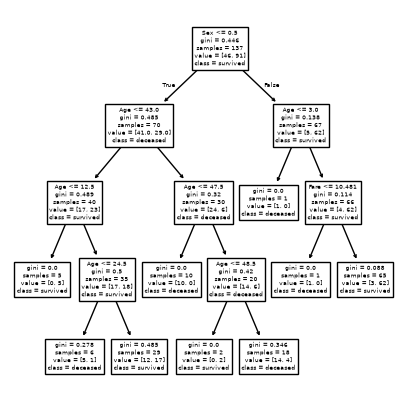

In [13]:
model_pruned = DecisionTreeClassifier(random_state=20, ccp_alpha=0.012).fit(X_train, y_train)
fig = plt.figure(figsize = (5, 5))
plot_tree(model_pruned, feature_names = X.keys(), class_names = ['deceased', 'survived'])
plt.show()

In [14]:
preds = model_pruned.predict(X_test)
confusion_matrix(y_test, preds)

array([[ 8,  6],
       [ 4, 28]])